In [27]:
import os
import pandas as pd
import numpy as np
import pyarrow 
from datetime import datetime
import glob
import dask
import dask.dataframe as dd
import dask.array as da
import matplotlib.pyplot as plt
from dask.distributed import Client, wait

## Zadanie 1

### Wczytanie pliku do ramki pandas

In [28]:
df=pd.read_csv('zamowienia.csv',header=0,sep=";")
df.dtypes

Kraj                   str
Sprzedawca             str
Data zamowienia        str
idZamowienia         int64
Utarg              float64
dtype: object

### Wstawienie wartości NaN w kilku miejscach + zapisanie do pliku

In [29]:
df.loc[[15,40,120,300],"idZamowienia"]=np.nan
df.loc[[20,77,200],"Utarg"]=np.nan
df.loc[[25,90],"Kraj"]=np.nan
df.to_csv("zamowienia_missing.csv",sep=";",index=False)

### Wczytanie pliku do ramki dask + sprawdzenie typów danych

In [30]:
ddf_missing=dd.read_csv("zamowienia_missing.csv",sep=";")
ddf_missing.dtypes

Kraj                string
Sprzedawca          string
Data zamowienia     string
idZamowienia       float64
Utarg              float64
dtype: object

Pliki mają w większości oryginalne typy, poza idZamowienia, z inta na float się zmienił.

### Obliczenia na ramce dask

In [31]:
print(ddf_missing.isna().sum().compute())
ddf_missing["Utarg"].sum().compute()

Kraj               2
Sprzedawca         0
Data zamowienia    0
idZamowienia       4
Utarg              3
dtype: int64


np.float64(1225285.7999999998)

### Sample rows

In [32]:
for sr in [1,10,100,1000]:
    d=dd.read_csv("zamowienia_missing.csv",sep=";",sample_rows=sr)
    print(sr,d["idZamowienia"].dtype,d["Utarg"].sum().compute())

1 float64 1225285.7999999998
10 float64 1225285.7999999998
100 float64 1225285.7999999998
1000 float64 1225285.7999999998


Błąd się nie pojawił

## Zadanie 2

### Testowe obliczenia i sprawdzenie w jupyter lab plugina dashbourda daska

In [33]:
client=Client(n_workers=2,threads_per_worker=2,memory_limit="3.5GiB")
print(client.dashboard_link)

d:\analizadaych\.venv\Lib\site-packages\distributed\node.py:195: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 53827 instead
  warnings.warn(


http://127.0.0.1:53827/status


In [34]:
da.random.normal(5,0.2,size=(20_000,20_000), chunks=(2000,2000)).mean(axis=0).compute()

array([4.99831335, 4.99686388, 5.00139271, ..., 5.00250289, 5.00019988,
       5.00003953], shape=(20000,))

![Dashboard Dask](jupyterlab.png)

## Zadanie 3

In [35]:
files=sorted(glob.glob(os.path.join("data","*.parquet")))
print("Liczba plikow:",len(files))

Liczba plikow: 8


### Wczytanie bez optymalizacji

In [36]:
start=datetime.now()
ddf=dd.read_parquet(files)
ddf=ddf.persist()
wait(ddf)
time_load_raw=datetime.now()-start
print("Czas wczytania:", time_load_raw)

Czas wczytania: 0:00:04.717563


In [37]:
print("Liczba wierszy",len(ddf))
print("Pamięć:", ddf.memory_usage(deep=True).sum().compute() /1024**3, "GiB")

Liczba wierszy 9178864
Pamięć: 3.846008184365928 GiB


## Zadanie 4

### Top 10 użytkowników z najwyższą liczbą like


In [38]:
start=datetime.now()
top10=ddf.groupby("username")["likes"].sum().nlargest(10).compute()
timetop10=datetime.now()-start
print(top10)
print("Czas:",timetop10)

username
lilireinhart       40375292
instagram          29864166
jamescharles       26067462
lizakoshy          19217644
433                16457870
amandacerny        15019135
akshaykumar        13352324
maisie_williams    12808999
chiaraferragni     11709658
claireholt         10109849
Name: likes, dtype: int64
Czas: 0:00:07.898936


### Pierwsze półrocze 2019

In [39]:
start=datetime.now()
pol2019=ddf[(ddf["date"]>="2019-01-01")&(ddf["date"]<"2019-07-01")]
count=len(pol2019)
time_2019=datetime.now()-start
print("Liczba wierszy:",count)
print("Czas:",time_2019)
pol2019.head()

Liczba wierszy: 5763240
Czas: 0:00:20.463345


,sid,sid_profile,post_id,profile_id,date,post_type,description,likes,comments,username,bio,following,followers,num_posts,is_business_account,lang,category
2,28370905,3496776,Bunhd1DFVAG,2237947779,2019-03-05 08:03:11,1,Tech Tuesday. Been flat out on the tools. Got ...,168,3,andylund_,"Professional Bicycle technician, Intense Racin...",520,1204,494,False,en,science_&_technology
4,32170690,3496776,BuDfIyslzfw,2237947779,2019-02-19 08:10:11,1,Solid effort on the bar turn.\nFully turned.\n...,145,2,andylund_,"Professional Bicycle technician, Intense Racin...",520,1204,494,False,en,diaries_&_daily_life
5,14315358,3496776,BxJsMDpA2yH,2237947779,2019-05-07 08:33:51,1,Annual springtime flora picture.\nTurn bars in...,124,2,andylund_,"Professional Bicycle technician, Intense Racin...",520,1204,494,False,en,arts_&_culture
6,8304346,3496776,Bt5LFpZlm3z,2237947779,2019-02-15 08:02:35,1,Laps in spring like conditions. Getting these ...,150,3,andylund_,"Professional Bicycle technician, Intense Racin...",520,1204,494,False,en,sports
7,14315346,3496776,BxZIzaQhS-o,2237947779,2019-05-13 08:32:30,1,Cheers Scotland 🏴󠁧󠁢󠁳󠁣󠁴󠁿 See you in a few weeks...,166,2,andylund_,"Professional Bicycle technician, Intense Racin...",520,1204,494,False,en,sports


## Zadanie 5

In [40]:
del ddf,pol2019
client.restart()

2026-10-10 16:48:33,293 - distributed.nanny - WARNING - Restarting worker (status=Status.running)
2026-10-10 16:48:33,359 - distributed.nanny - WARNING - Restarting worker (status=Status.running)


### Typy danych

In [41]:
dtypes = {
    "lang": "category", "bio": "category", "username": "category",
    "description": "category", "category": "category",
    "sid": "uint32", "sid_profile": "int32", "profile_id": "uint64",
    "post_type": "uint8", "likes": "uint32", "comments": "uint32",
    "following": "uint32", "followers": "uint32", "num_posts": "uint32",
}

In [42]:
start=datetime.now()
ddf_opt=dd.read_parquet(files).astype(dtypes)
ddf_opt["date"]=dd.to_datetime(ddf_opt["date"])
ddf_opt=ddf_opt.persist()
wait(ddf_opt)
time_load=datetime.now()-start
print("Czas:", time_load)
print("Pamięć:",ddf_opt.memory_usage(deep=True).sum().compute() /1024**3,"GiB")

Czas: 0:00:11.236327
Pamięć: 2.276519613340497 GiB


In [43]:
start=datetime.now()
top10opt=ddf_opt.groupby("username",observed=True)["likes"].sum().nlargest(10).compute()
timetop10opt=datetime.now()-start

start=datetime.now()
countopt=len(ddf_opt[(ddf_opt["date"]>="2019-01-01")&(ddf_opt["date"]<"2019-07-01")])
time2019opt=datetime.now()-start

print("Wczytanie:", time_load_raw,"<->", time_load)
print("Top10:",timetop10,"<->",timetop10opt)
print("Półrocze:",time_2019,"<->",time2019opt)
print("Wyniki:",count,"<->",countopt)


Wczytanie: 0:00:04.717563 <-> 0:00:11.236327
Top10: 0:00:07.898936 <-> 0:00:01.521636
Półrocze: 0:00:20.463345 <-> 0:00:00.531104
Wyniki: 5763240 <-> 5763240


### Graf wywołań

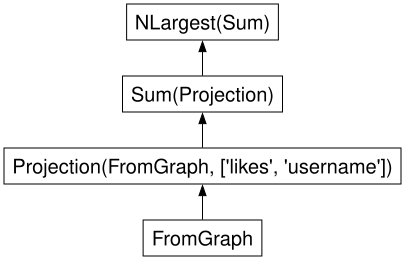

In [44]:
ddf_opt.groupby("username", observed=True)["likes"].sum().nlargest(10).visualize()

## Zadanie 6

In [45]:
def mean_time(chunks,repeats=10):
    times=[]
    for _ in range(repeats):
        darr=da.random.normal(5,0.2,size=(20_000,20_000),chunks=chunks)
        start=datetime.now()
        darr.mean(axis=0).compute()
        times.append((datetime.now()-start).total_seconds())
    return np.mean(times)

results={}
for chunks in ["auto",(500,500),(1000,1000),(2000,2000),(5000,5000),(10000,10000)]:
    results[str(chunks)]=mean_time(chunks)
    print(chunks,":",round(results[str(chunks)],2),"s")

auto : 1.76 s
(500, 500) : 6.74 s
(1000, 1000) : 2.81 s
(2000, 2000) : 1.81 s
(5000, 5000) : 1.69 s
(10000, 10000) : 1.64 s


### Wniosek: zbyt małe chunki są dużo wolniejsze niż auto w dasku. Rozmiary (2000-10000) są podobne czasowo lub lepsze od automatycznego podziału